In [1]:
from langchain_core.prompts import PromptTemplate
from langchain_ollama import ChatOllama

from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OLLAMA_API_KEY")
headers = { "Authorization" : f"Bearer {api_key}"}

llm = ChatOllama(
   base_url="https://ollama.com",
   model="gemma4:31b-cloud",
   client_kwargs={"headers": headers},
   temperature=0.2,
   reasoning=True
)

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated

class arxivState(TypedDict):
    input_query: Annotated[str, "user_input_query"]         # 사용자 질의
    keyword: Annotated[list[str], "search keywords"]        # 질의로부터 뽑아낸 검색 키워드
    papers: Annotated[list[dict], "retrieved papers"]       # 검색 결과 논문들
    select_papers: Annotated[list[str], "title list of selected papers from retrieved"]  # 검색 결과 논문 제목들

In [3]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

def get_keyword(user_query:str):
    parser = CommaSeparatedListOutputParser()

    prompt = PromptTemplate(
        template="""
        사용자의 질문을 검색엔진에 검색하기 위하여, 사용자의 질문으로부터 1개 이상의 적절한 검색 keyword를 추출

        **User Query**
        {user_query}
        
        **규칙**
        1. keyword는 반드시 영어로 반환
        2. 적합도가 높은 순으로 반환
        3. {format_instructions}
        
        """,
        input_variables=['input'],
        partial_variables={'format_instructions' : parser.get_format_instructions()}
    )

    keyword_chain = prompt | llm | parser
    res = keyword_chain.invoke({'user_query' : user_query})

    return res

In [4]:
def keyword_extract_node(state : arxivState) -> dict:
    return {'keyword' : get_keyword(state['input_query'])}

In [5]:
### 논문 긁어오기
import requests 
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse, quote, unquote, urljoin
from urllib.request import urlretrieve
import os

In [6]:
def get_paper(query:str) -> dict:
    url = "https://arxiv.org/search/?"

    query_dict = {'query': [query],
                'searchtype': ['all'],
                'abstracts': ['show'],
                'order': [''],
                'size': ['25']}

    bs = BeautifulSoup(requests.get(url + urlencode(query_dict, doseq=True)).text)
    arxiv_results= bs.find('ol', class_="breathe-horizontal").find_all('li', {'class' : 'arxiv-result'})

    papers = {}
    PDF_PATH = "https://arxiv.org/pdf/"

    for x in arxiv_results:
        title = x.find("p", {'class' : 'title is-5 mathjax'}).text.strip()
        papers[title] = {}
        papers[title]["authors"] = " ".join([y.text for y in x.find("p" , {'class' : 'authors'}).find_all('a') ] )
        papers[title]["abstract"] = x.find('span', class_="abstract-full has-text-grey-dark mathjax").text.strip().replace("△ Less", "")
        papers[title]["pdf_path"] = PDF_PATH + x.find("div", class_="is-marginless").find_all("a")[0]["href"].split("/")[-1]

    return papers

In [7]:
def get_paper_node(state : arxivState) -> dict:
    res = {}
    for query in state['keyword']: res.update(get_paper(query))
    return {"papers" : res}

In [8]:
agent = StateGraph(arxivState)

agent.add_node("keyword_extract", keyword_extract_node)
agent.add_node("paper_get", get_paper_node)

agent.add_edge(START, "keyword_extract")
agent.add_edge("keyword_extract", "paper_get")
agent.add_edge("paper_get", END)
myagent = agent.compile()

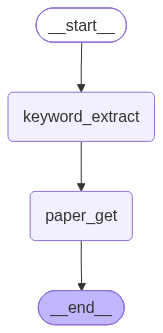

In [9]:
myagent

In [10]:
res = myagent.invoke({"input_query" : "LLM이 되면서 실질적으로 개발 효율이 좋아졌어? 그리고 그거 때문에 개발자의 고용이 불안정해졌어?"})

In [11]:
res

{'input_query': 'LLM이 되면서 실질적으로 개발 효율이 좋아졌어? 그리고 그거 때문에 개발자의 고용이 불안정해졌어?',
 'keyword': ['LLM',
  'software development productivity',
  'AI impact on developer employment',
  'coding efficiency',
  'developer job security'],
 'papers': {'AgentGym2: Benchmarking Large Language Model Agents in De-Idealized Real-World Environments': {'authors': 'Zhiheng Xi Dingwen Yang Jiaqi Liu Jixuan Huang Honglin Guo Baodai Huang Tinggang Chen Qi Zhang Zhonghang Lu Chenyu Liu Jiajun Sun Jiazheng Zhang Dingwei Zhu Xin Guo Junzhe Wang Zhihao Zhang Yuming Yang Junjie Ye Minghe Gao Dongrui Liu Jiaming Ji Guohao Li Tao Gui Qi Zhang Xuanjing Huang',
   'abstract': "Language agents, i.e., LLM agents, progress rapidly and are increasingly deployed in production environments. This trend underscores the urgent need for rigorous and realistic evaluations. However, most existing benchmarks evaluate agents in simplified, idealized settings. They typically rely on pre-packaged tool interfaces, overlook critical step

In [12]:

from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

class paper_selector_output(BaseModel):
    selected_papers_title : list[str] = Field("선택된 논문 제목 리스트")

def paper_selector_node(state: arxivState) -> dict:
    """
    검색된 논문 중 쿼리에 가장 적합한 논문을 찾아오고 저장함
    """

    ## Select
    parser = PydanticOutputParser(pydantic_object=paper_selector_output)

    prompt = PromptTemplate(
        template="""사용자 질문과 논문의 title : abstract 목록이 제공됨. 질문에 가장 적합한 답을 낼 수 있는 논문을 선택해야 함.

        **RULE**
        - 반드시 주어진 논문 중에서만 선택할 것
        - 적합성이 높은 순서로 답변할 것
        - 적합한 논문이 없는 경우 빈 리스트를 반환할 것

        **output format**
        {format_instructions}

        **사용자 질문**
        {input_query}

        **논문 목록**
        {papers}

        """,
        partial_variables={
            "input_query" : state["input_query"],
            "papers" : [{"title" : title, "abstract" : state["papers"][title]["abstract"]} for title in state["papers"].keys()],
            "format_instructions" : parser.get_format_instructions(),
            },
    )

    chain = prompt | llm | parser
    res = chain.invoke({})

    ## Save
    


    return { "select_papers" : res}

In [13]:
agent = StateGraph(arxivState)

agent.add_node("keyword_extract", keyword_extract_node)
agent.add_node("paper_get", get_paper_node)
agent.add_node("paper_select", paper_selector_node)

agent.add_edge(START, "keyword_extract")
agent.add_edge("keyword_extract", "paper_get")
agent.add_edge("paper_get", "paper_select")
agent.add_edge("paper_select", END)
myagent = agent.compile()

In [14]:
res = myagent.invoke({"input_query" : "LLM이 되면서 실질적으로 개발 효율이 좋아졌어? 그리고 그거 때문에 개발자의 고용이 불안정해졌어?"})

In [17]:
res["select_papers"].selected_papers_title

['Agentic AI in the Software Development Lifecycle: Architecture, Empirical Evidence, and the Reshaping of Software Engineering',
 'The Rise of AI-Native Software Engineering: Implications for Practice, Education, and the Future Workforce',
 'From Determinism to Delegation: AI-Native Software Engineering and the Evolution of the Agentic Engineer',
 'Augmenting or Automating Labor? The Effect of AI Development on New Work, Employment, and Wages',
 'Skill-Based Labor Market Polarization in the Age of AI: A Comparative Analysis of India and the United States',
 "Developers' Experience with Generative AI Beyond Productivity Assessment -- Insights from an Empirical Mixed-Methods Field Study",
 'Artificial Intelligence and the Dual Paradoxes: Examining the Interplay of Efficiency, Resource Consumption, and Labor Dynamics']

In [ ]:
## TODO
# 논문 선택까지 했음
# 이제 다운로드 하고 요약까지 하고, 결과 다시 판별하는거 ㄱㄱ
# RunableBranch? add_conditional_edge? Litaral

## ISSUE 기록 
# paper_selector_node <- 이거 굳이 LLM한테 물어봐야할까? 그냥 vectorDB로 올리는게 낫지 않을까? 
# 

In [ ]:

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

class summary(BaseModel):
    summary : str = Field(description="주어진 논문에 대해서 요약을 300자 이내로 요약할 것")

from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

parser = PydanticOutputParser(pydantic_object=summary)
summary_prompt = PromptTemplate(
    template="주어진 논문을 요약하는 AI입니다. 핵심이 잘 포함되도록 요약할 것 \n\n{format_instructions}\n\n\n\n텍스트: {context}",
    input_variables=["context"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
chain = summary_prompt | llm |  parser

article = "\n\n".join([x.page_content for x in documents])
document_results = chain.invoke({'context' : article})

In [ ]:


PDF_PATH = "./papers/"

for FOLDER in res.get('keyword'):
    for FILE_NAME in os.listdir(PDF_PATH + FOLDER):
        FULL_PATH = PDF_PATH + FOLDER + "/" + FILE_NAME
        print(FULL_PATH)

        loader = PyPDFLoader(FULL_PATH)
        documents = loader.load()